In [1]:
import sys
sys.path.append("/Users/hnq/Desktop/licenta/cod_plante")

import torch
import torch.nn as nn
from torchvision import models
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    top_k_accuracy_score
)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from tqdm.notebook import tqdm
import time
from pathlib import Path
import pandas as pd
from src.data_loaders import get_dataloaders, get_class_names, get_device

train_loader, val_loader = get_dataloaders()
class_names = get_class_names()
device = get_device()

print(f"Device: {device}")
print(f"Number of classes: {len(class_names)}")
print(f"Val batches: {len(val_loader)}")

Device: mps
Number of classes: 38
Val batches: 340


In [2]:
class CustomCNN(nn.Module):
    def __init__(self, num_classes=38):
        super().__init__()
        
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)
        
        self.relu = nn.ReLU(inplace=True)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(256 * 14 * 14, 512)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, num_classes)
        
    def forward(self, x):
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        x = self.pool(self.relu(self.bn2(self.conv2(x))))
        x = self.pool(self.relu(self.bn3(self.conv3(x))))
        x = self.pool(self.relu(self.bn4(self.conv4(x))))
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x


print("CustomCNN class defined")

CustomCNN class defined


In [3]:
MODEL_PATH = Path("/Users/hnq/Desktop/licenta/cod_plante/models")

model_cnn = CustomCNN(num_classes=38)
model_cnn.load_state_dict(torch.load(MODEL_PATH / "n03_cnn_custom_scratch.pth", map_location=device))
model_cnn = model_cnn.to(device)
model_cnn.eval()
print("Custom CNN loaded")

model_eff = models.efficientnet_b4(weights=None)
num_features = model_eff.classifier[1].in_features
model_eff.classifier[1] = nn.Linear(num_features, 38)
model_eff.load_state_dict(torch.load(MODEL_PATH / "n04_efficientnet_b4_final.pth", map_location=device))
model_eff = model_eff.to(device)
model_eff.eval()
print("EfficientNet-B4 loaded")

print("\nBoth models ready for evaluation")

Custom CNN loaded
EfficientNet-B4 loaded

Both models ready for evaluation


In [4]:
def get_predictions(model, loader, device):
    model.eval()
    all_preds = []
    all_probs = []
    all_labels = []
    inference_times = []
    
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Predicting", leave=False):
            images = images.to(device)
            labels = labels.to(device)
            
            start = time.time()
            outputs = model(images)
            elapsed = time.time() - start
            
            inference_times.append(elapsed * 1000 / images.size(0))
            
            probs = torch.softmax(outputs, dim=1)
            _, predicted = outputs.max(1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    return (
        np.array(all_preds),
        np.array(all_probs),
        np.array(all_labels),
        np.mean(inference_times)
    )


print("Inference function defined")

Inference function defined


In [5]:
preds_cnn, probs_cnn, labels_cnn, time_cnn = get_predictions(model_cnn, val_loader, device)
print(f"Done. Average inference time: {time_cnn:.2f} ms/image")

preds_eff, probs_eff, labels_eff, time_eff = get_predictions(model_eff, val_loader, device)
print(f"Done. Average inference time: {time_eff:.2f} ms/image")

Predicting:   0%|          | 0/340 [00:00<?, ?it/s]

Done. Average inference time: 0.06 ms/image


Predicting:   0%|          | 0/340 [00:00<?, ?it/s]

Done. Average inference time: 4.58 ms/image


In [9]:
def calculate_metrics(preds, probs, labels, model_name):
    accuracy = accuracy_score(labels, preds)
    f1_macro = f1_score(labels, preds, average='macro')
    f1_weighted = f1_score(labels, preds, average='weighted')
    precision_macro = precision_score(labels, preds, average='macro', zero_division=0)
    recall_macro = recall_score(labels, preds, average='macro', zero_division=0)
    
    top3_acc = top_k_accuracy_score(labels, probs, k=3)
    
    print(f"{model_name} - Detailed Metrics")
    print(f"Accuracy:           {accuracy * 100:.2f}%")
    print(f"Top-3 Accuracy:     {top3_acc * 100:.2f}%")
    print(f"F1-Score (macro):   {f1_macro:.4f}")
    print(f"F1-Score (weighted):{f1_weighted:.4f}")
    print(f"Precision (macro):  {precision_macro:.4f}")
    print(f"Recall (macro):     {recall_macro:.4f}\n")
    
    return {
        'model': model_name,
        'accuracy': accuracy * 100,
        'top3_accuracy': top3_acc * 100,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'precision_macro': precision_macro,
        'recall_macro': recall_macro
    }

metrics_cnn = calculate_metrics(preds_cnn, probs_cnn, labels_cnn, "Custom CNN")
metrics_eff = calculate_metrics(preds_eff, probs_eff, labels_eff, "EfficientNet-B4")

Custom CNN - Detailed Metrics
Accuracy:           94.16%
Top-3 Accuracy:     99.38%
F1-Score (macro):   0.9000
F1-Score (weighted):0.9397
Precision (macro):  0.9080
Recall (macro):     0.8982

EfficientNet-B4 - Detailed Metrics
Accuracy:           97.42%
Top-3 Accuracy:     99.75%
F1-Score (macro):   0.9613
F1-Score (weighted):0.9742
Precision (macro):  0.9621
Recall (macro):     0.9611



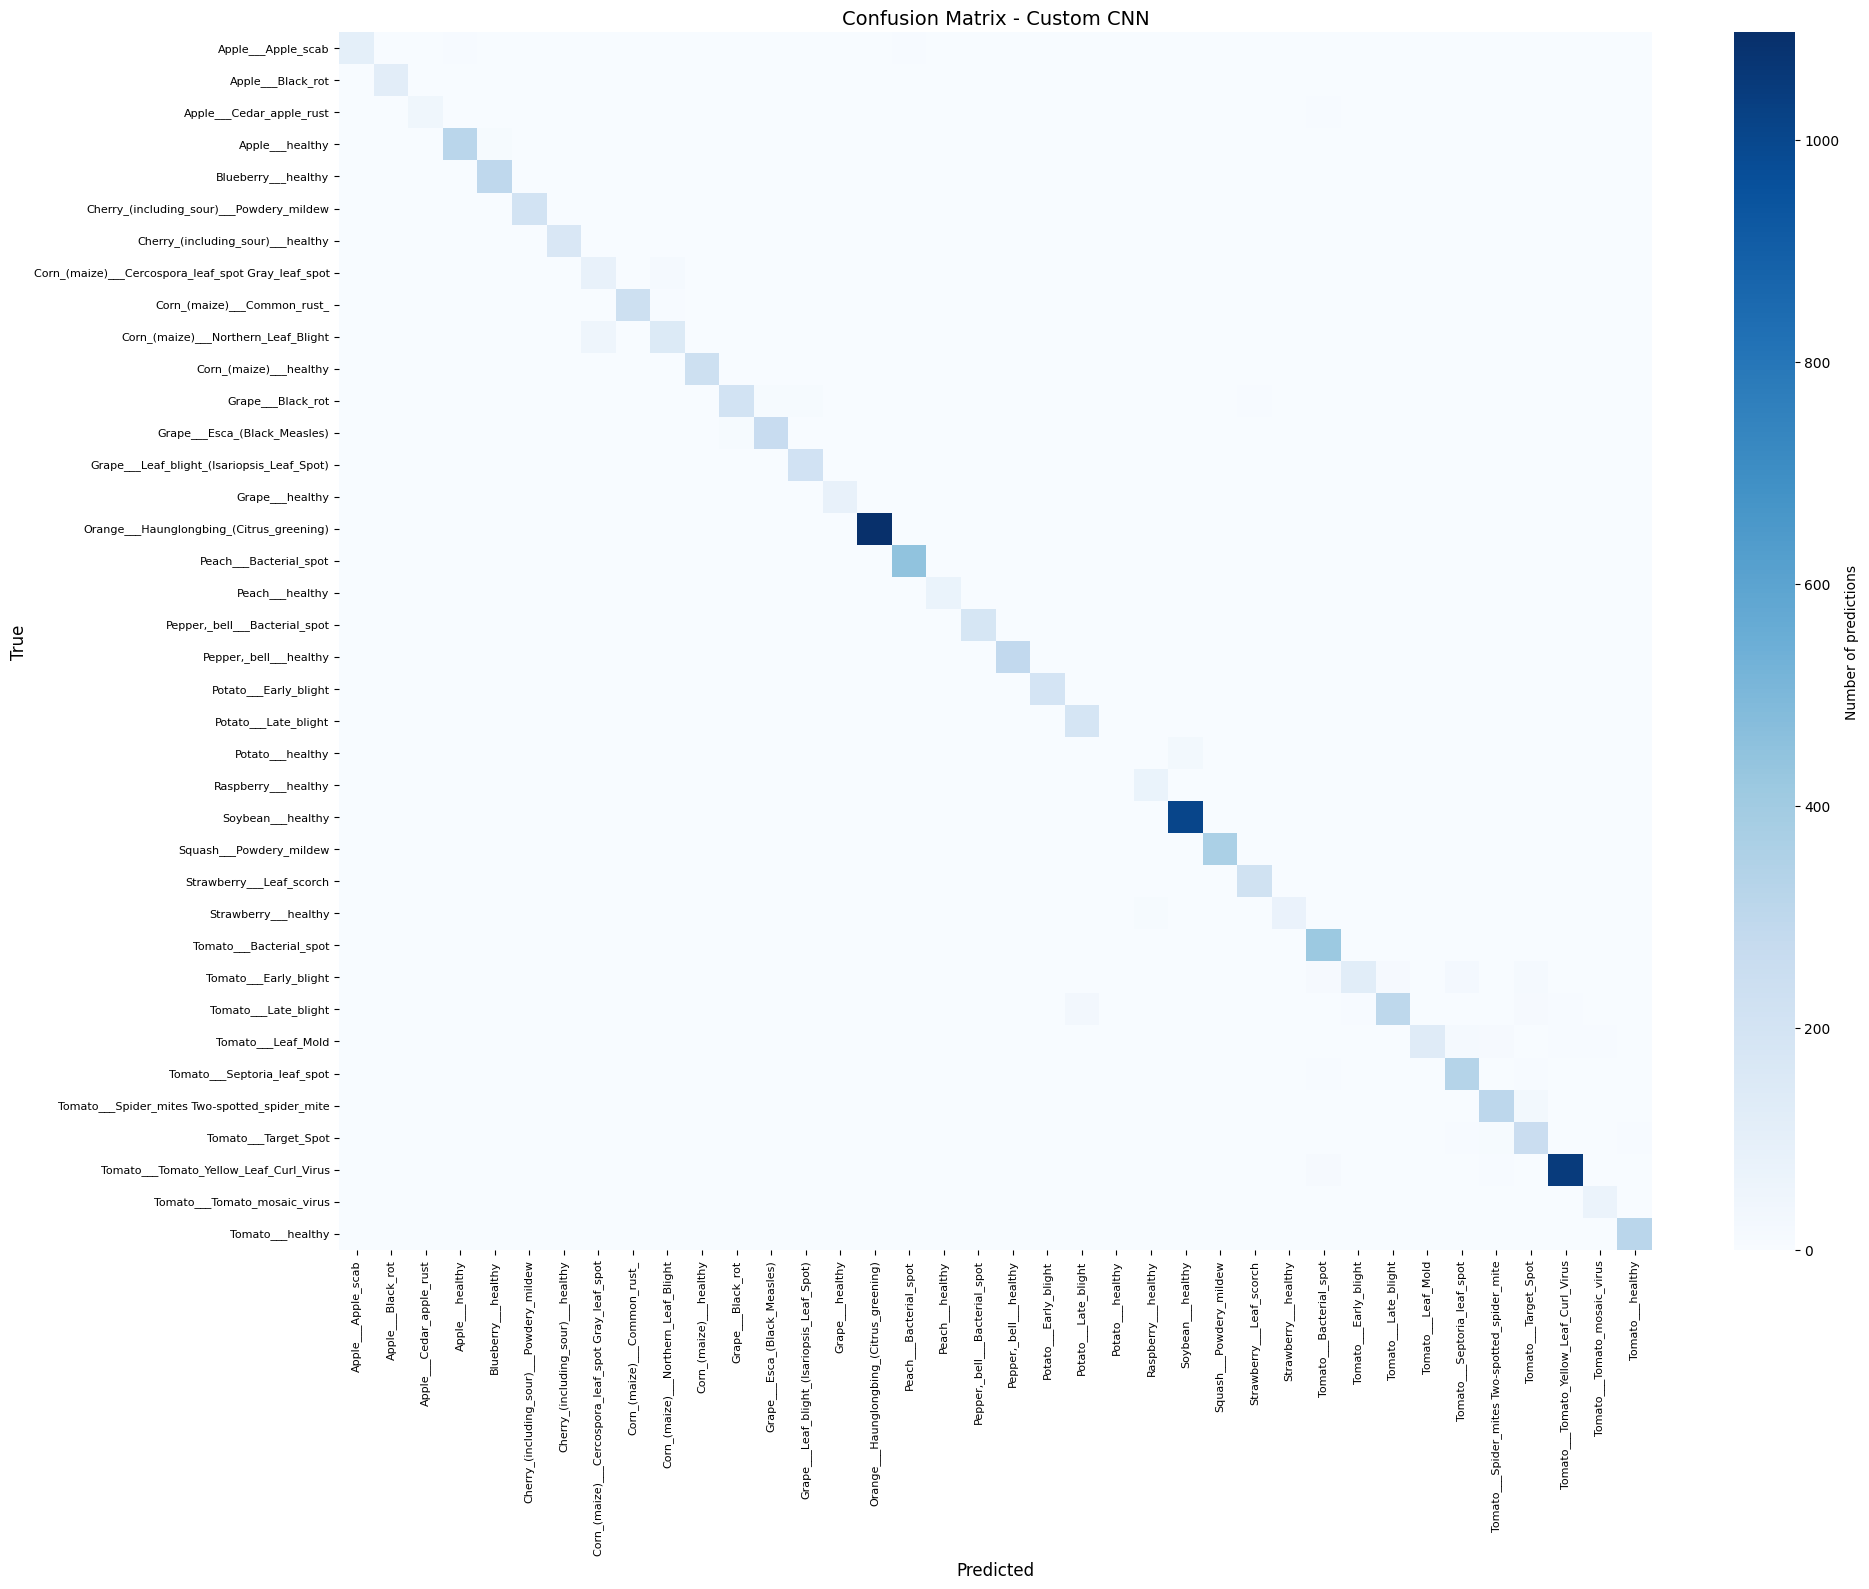

Confusion matrix saved to n05_confusion_matrix_cnn.png


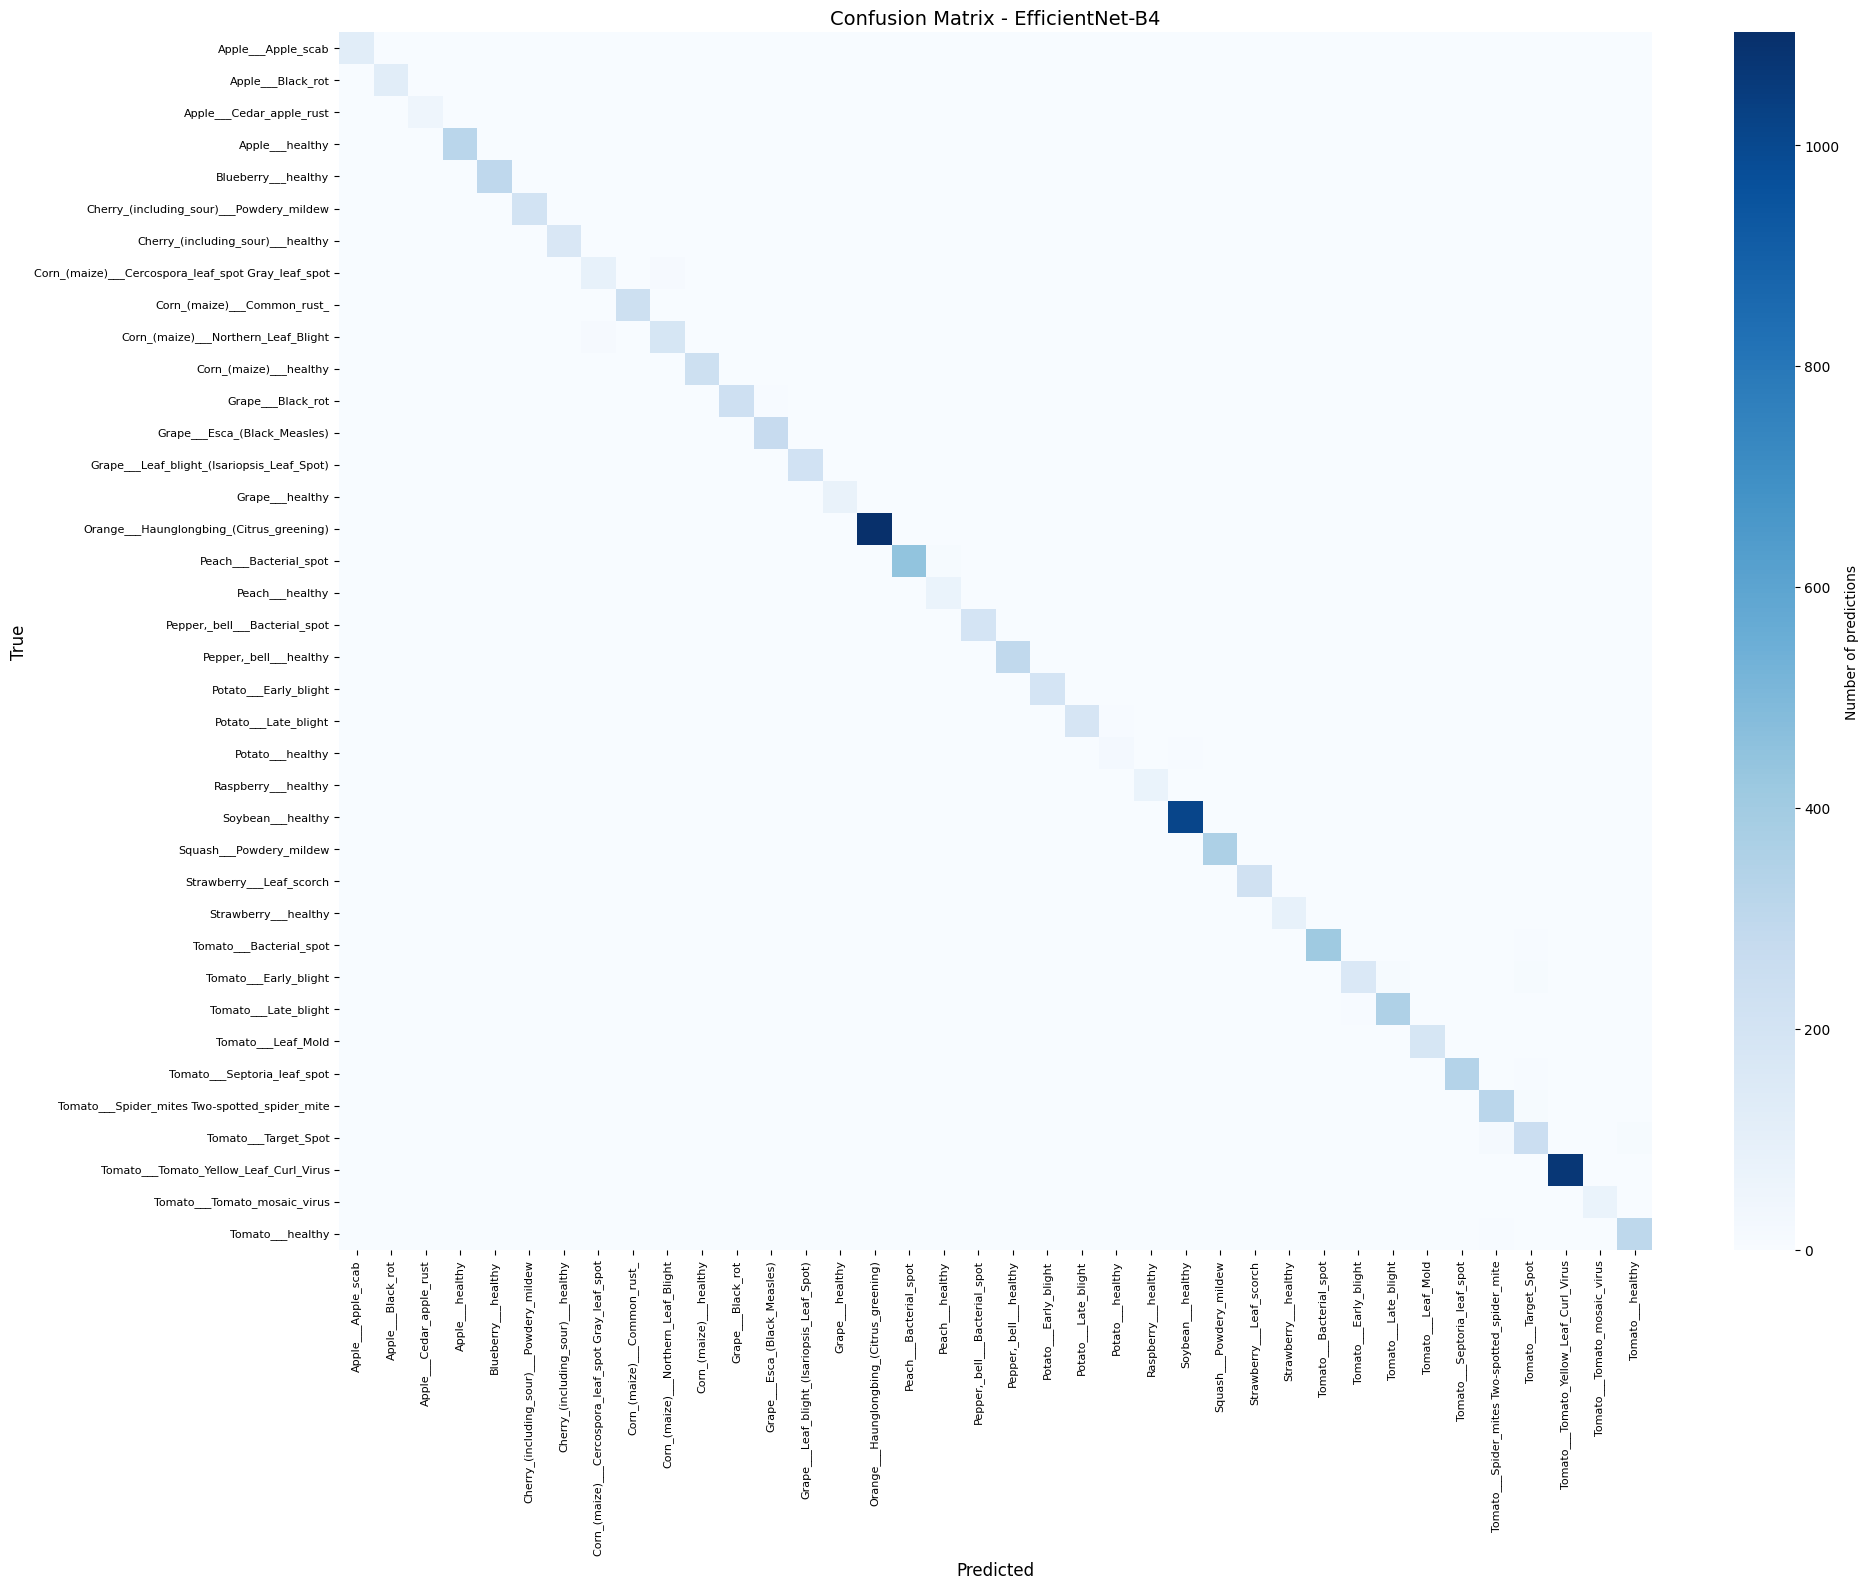

Confusion matrix saved to n05_confusion_matrix_efficientnet.png


In [10]:
def plot_confusion_matrix(preds, labels, class_names, model_name, save_path):
    cm = confusion_matrix(labels, preds)
    
    plt.figure(figsize=(20, 16))
    sns.heatmap(
        cm,
        annot=False,
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names,
        cbar_kws={'label': 'Number of predictions'}
    )
    plt.xlabel('Predicted', fontsize=12)
    plt.ylabel('True', fontsize=12)
    plt.title(f'Confusion Matrix - {model_name}', fontsize=14)
    plt.xticks(rotation=90, fontsize=8)
    plt.yticks(rotation=0, fontsize=8)
    plt.tight_layout()
    plt.savefig(save_path, dpi=100, bbox_inches='tight')
    plt.show()
    
    print(f"Confusion matrix saved to {save_path}")
    return cm


cm_cnn = plot_confusion_matrix(
    preds_cnn, labels_cnn, class_names,
    "Custom CNN",
    "n05_confusion_matrix_cnn.png"
)

cm_eff = plot_confusion_matrix(
    preds_eff, labels_eff, class_names,
    "EfficientNet-B4",
    "n05_confusion_matrix_efficientnet.png"
)

MODEL COMPARISON
                   Metric Custom CNN EfficientNet-B4
             Accuracy (%)      94.16           97.42
       Top-3 Accuracy (%)      99.38           99.75
         F1-Score (macro)     0.9000          0.9613
      F1-Score (weighted)     0.9397          0.9742
        Precision (macro)     0.9080          0.9621
           Recall (macro)     0.8982          0.9611
Inference time (ms/image)       0.06            4.58
         Total parameters      26.1M           19.0M

Table saved to n05_comparison_table.csv


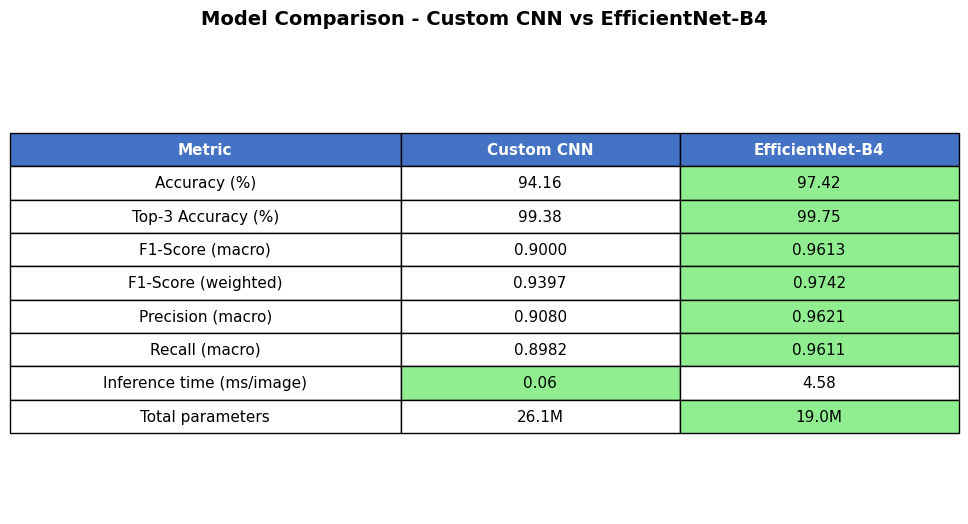


Visual table saved to n05_comparison_table.png


In [12]:
comparison_data = {
    'Metric': [
        'Accuracy (%)',
        'Top-3 Accuracy (%)',
        'F1-Score (macro)',
        'F1-Score (weighted)',
        'Precision (macro)',
        'Recall (macro)',
        'Inference time (ms/image)',
        'Total parameters'
    ],
    'Custom CNN': [
        f"{metrics_cnn['accuracy']:.2f}",
        f"{metrics_cnn['top3_accuracy']:.2f}",
        f"{metrics_cnn['f1_macro']:.4f}",
        f"{metrics_cnn['f1_weighted']:.4f}",
        f"{metrics_cnn['precision_macro']:.4f}",
        f"{metrics_cnn['recall_macro']:.4f}",
        f"{time_cnn:.2f}",
        "26.1M"
    ],
    'EfficientNet-B4': [
        f"{metrics_eff['accuracy']:.2f}",
        f"{metrics_eff['top3_accuracy']:.2f}",
        f"{metrics_eff['f1_macro']:.4f}",
        f"{metrics_eff['f1_weighted']:.4f}",
        f"{metrics_eff['precision_macro']:.4f}",
        f"{metrics_eff['recall_macro']:.4f}",
        f"{time_eff:.2f}",
        "19.0M"
    ],
}

df_comparison = pd.DataFrame(comparison_data)
print("MODEL COMPARISON")
print(df_comparison.to_string(index=False))

df_comparison.to_csv("n05_comparison_table.csv", index=False)
print(f"\nTable saved to n05_comparison_table.csv")

fig, ax = plt.subplots(figsize=(12, 6))
ax.axis('off')
table = ax.table(
    cellText=df_comparison.values,
    colLabels=df_comparison.columns,
    cellLoc='center',
    loc='center',
    colWidths=[0.35, 0.25, 0.25]
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 2)

for i in range(len(df_comparison.columns)):
    table[(0, i)].set_facecolor('#4472C4')
    table[(0, i)].set_text_props(weight='bold', color='white')

for row_idx in range(1, len(df_comparison) + 1):
    metric = df_comparison.iloc[row_idx - 1]['Metric']
    cnn_val = df_comparison.iloc[row_idx - 1]['Custom CNN']
    eff_val = df_comparison.iloc[row_idx - 1]['EfficientNet-B4']
    
    if metric in ['Inference time (ms/image)', 'Total parameters']:
        try:
            cnn_num = float(cnn_val.replace('M', ''))
            eff_num = float(eff_val.replace('M', ''))
            if cnn_num < eff_num:
                table[(row_idx, 1)].set_facecolor('#90EE90')
            else:
                table[(row_idx, 2)].set_facecolor('#90EE90')
        except:
            pass
    else:
        try:
            if float(cnn_val) > float(eff_val):
                table[(row_idx, 1)].set_facecolor('#90EE90')
            else:
                table[(row_idx, 2)].set_facecolor('#90EE90')
        except:
            pass

plt.title('Model Comparison - Custom CNN vs EfficientNet-B4', fontsize=14, pad=20, weight='bold')
plt.savefig("n05_comparison_table.png", dpi=100, bbox_inches='tight')
plt.show()

print(f"\nVisual table saved to n05_comparison_table.png")